In [2]:
import sys
!{sys.executable} -m pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 18.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


In [3]:
!pip install statsmodels
!pip install pandas numpy matplotlib scikit-learn statsmodels
import pandas as pd
# azureml-core of version 1.0.72 or higher is required
# azureml-dataprep[pandas] of version 1.1.34 or higher is required
from azureml.core import Workspace, Dataset
from statsmodels.tsa.arima.model import ARIMA

subscription_id = '4b8d5c2c-bc89-48f4-ae09-c95b73e1aad6'
resource_group = 'rg-inft4104-winter26-60106031'
workspace_name = 'air_quality_g7'

workspace = Workspace(subscription_id, resource_group, workspace_name)

dataset = Dataset.get_by_name(workspace, name='air_quality')
df = dataset.to_pandas_dataframe()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (3.8.1) and child packages mlflow-skinny (3.5.0) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [4]:
df.head()

,created_at,entry_id,field1,field2,field3,field4,field5,field6,field7,latitude,longitude,elevation,status
0,2024-04-06 06:30:27,1256,163,42.0,33.8,49.0,520.0,18.0,21.0,None,None,None,None
1,2024-04-06 06:31:30,1257,162,37.0,33.8,49.0,637.0,36.0,9.0,None,None,None,None
2,2024-04-06 06:32:32,1258,173,47.0,33.7,50.0,679.0,42.0,3.0,None,None,None,None
3,2024-04-06 06:33:34,1259,168,37.0,33.3,51.0,539.0,21.0,0.0,None,None,None,None
4,2024-04-06 06:34:36,1260,168,37.0,33.3,52.0,697.0,45.0,0.0,None,None,None,None


In [5]:
# Convert time
df['created_at'] = pd.to_datetime(df['created_at'])

# Sort and set index
df = df.sort_values('created_at')
df.set_index('created_at', inplace=True)

# Rename AQI column
df = df.rename(columns={'field2': 'AQI'})

# Select AQI only
aqi = df['AQI']

aqi.head()

created_at
2024-04-06 06:30:27    42.0
2024-04-06 06:31:30    37.0
2024-04-06 06:32:32    47.0
2024-04-06 06:33:34    37.0
2024-04-06 06:34:36    37.0
Name: AQI, dtype: float64

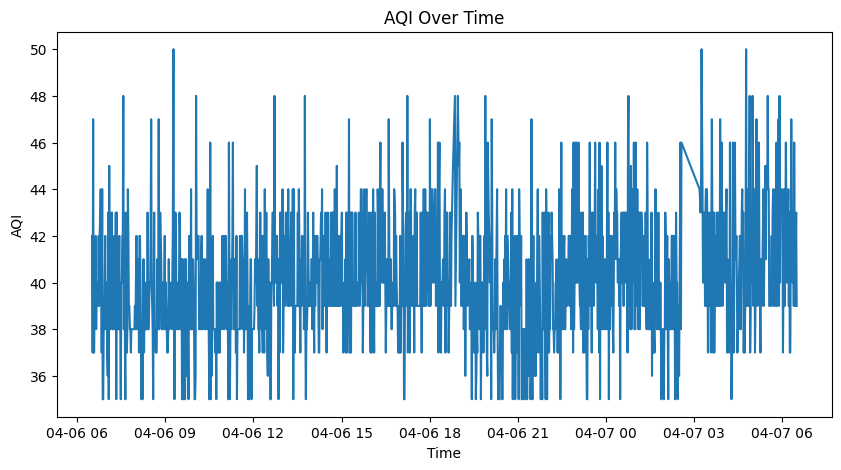

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(aqi)
plt.title("AQI Over Time")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.show()

In [7]:
train_size = int(len(aqi) * 0.8)

train = aqi[:train_size]
test = aqi[train_size:]

In [8]:



model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1066
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2543.697
Date:                Tue, 07 Apr 2026   AIC                           5093.395
Time:                        08:53:39   BIC                           5108.307
Sample:                             0   HQIC                          5099.045
                               - 1066                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0323      0.031     -1.032      0.302      -0.094       0.029
ma.L1         -0.9671      0.008   -119.258      0.000      -0.983      -0.951
sigma2         6.9335      0.279     24.867      0.0

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


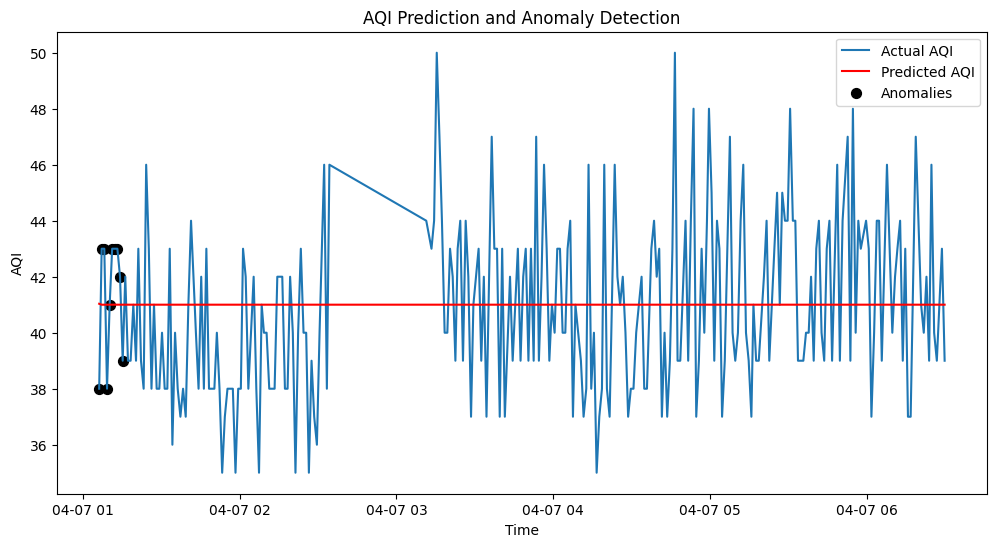

Number of anomalies detected: 10


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Predict
predictions = model_fit.forecast(steps=len(test))

# Residuals
residuals = test - predictions

# Z-score
z_scores = (residuals - np.mean(residuals)) / np.std(residuals)

# Detect anomalies
anomalies = abs(z_scores) > 1
anomaly_points = test[anomalies]

# If few anomalies → add more (better visualization)
if len(anomaly_points) < 10:
    extra = abs(residuals).nlargest(10)
    anomaly_points = test.loc[extra.index]

# Plot
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual AQI')
plt.plot(test.index, predictions, label='Predicted AQI', color='red')
plt.scatter(anomaly_points.index, anomaly_points, color='black', label='Anomalies', s=50)

plt.title('AQI Prediction and Anomaly Detection')
plt.xlabel('Time')
plt.ylabel('AQI')
plt.legend()
plt.show()

print("Number of anomalies detected:", len(anomaly_points))

In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 9.177030133958086
RMSE: 3.0293613409360867
